In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [ ]:
import statsmodels.api as sm
import statsmodels.formula.api as smf
import scipy

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
minority_df = pd.read_csv("/content/drive/MyDrive/minority1.csv")
minority_df

Mounted at /content/drive


,Total - Visible minority for the population in private households - 25% sample data,Total visible minority population,South Asian,Chinese,Black,Filipino,Arab,Latin American,Southeast Asian,West Asian,Korean,Japanese,"Visible minority, n.i.e.",Multiple visible minorities,Not a visible minority,Neighbourhood Number
0,33300,28035,13815,345,6125,2075,460,1600,530,415,130,45,1560,935,5265,1
1,31345,27975,10195,320,8315,1160,1985,1350,450,1835,75,0,1405,870,3370,2
2,9850,6705,2715,80,1590,205,290,645,250,370,20,0,300,240,3150,3
3,10375,5985,1530,110,1870,575,65,725,215,220,40,20,355,255,4395,4
4,9355,6465,780,130,2830,760,150,890,290,140,110,0,145,245,2890,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
153,12645,9050,1870,3470,570,215,715,360,295,275,635,150,145,345,3600,170
154,23180,8805,1630,1495,1755,550,210,1120,650,120,240,125,280,630,14380,171
155,12380,3900,620,1055,540,185,75,445,285,40,190,65,115,280,8485,172
156,15885,8160,1570,1050,1025,775,220,1050,245,1000,595,115,145,370,7730,173


# Racial hate crime incidents counting

In [ ]:
crimes_df = pd.read_csv("/content/drive/MyDrive/hatecrimes1.csv")
crimes_df

,_id,EVENT_UNIQUE_ID,OCCURRENCE_YEAR,OCCURRENCE_DATE,OCCURRENCE_TIME,REPORTED_YEAR,REPORTED_DATE,REPORTED_TIME,DIVISION,LOCATION_TYPE,...,RELIGION_BIAS,SEXUAL_ORIENTATION_BIAS,GENDER_BIAS,MULTIPLE_BIAS,PRIMARY_OFFENCE,HOOD_158,NEIGHBOURHOOD_158,HOOD_140,NEIGHBOURHOOD_140,ARREST_MADE
0,1,GO-2020813480,2014,2014-08-01,1200,2020,2020-04-30,1904,D33,Religious Place of Worship/Cultural Centre,...,Jewish,NaN,NaN,No,Wilful Promotion of Hatred,053,Henry Farm (53),053,Henry Farm (53),No
1,2,GO-2019601581,2016,2016-01-01,900,2019,2019-04-03,1956,D42,"House (Townhouse, Retirement Home, Garage, Veh...",...,NaN,Gay,NaN,No,This should be removed,144,Morningside Heights (144),131,Rouge (131),No
2,3,GO-2019728283,2016,2016-09-01,0,2019,2019-04-23,754,D53,"Educational Institution (Universities, College...",...,NaN,NaN,NaN,No,Assault With a Weapon,173,North Toronto (173),104,Mount Pleasant West (104),No
3,4,GO-2018698451,2017,2017-06-22,824,2018,2018-04-19,1015,D52,Streets/Roadways/Highway,...,NaN,NaN,Woman,No,Assault With a Weapon,164,Wellington Place (164),077,Waterfront Communities-The Island (77),Yes
4,5,GO-2018695170,2017,2017-09-05,900,2018,2018-04-19,1333,D53,"Educational Institution (Universities, College...",...,Jewish,NaN,NaN,No,Mischief Under $5000,099,Mount Pleasant East (99),099,Mount Pleasant East (99),No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1800,1801,GO-20242717397,2024,2024-12-16,1541,2024,2024-12-16,1623,D14,Streets/Roadways/Highway,...,NaN,Gay,NaN,No,Assault,080,Palmerston-Little Italy (80),080,Palmerston-Little Italy (80),No
1801,1802,GO-20242736685,2024,2024-12-19,815,2024,2024-12-19,954,D52,Streets/Roadways/Highway,...,Muslim,NaN,NaN,No,Assault,078,Kensington-Chinatown (78),078,Kensington-Chinatown (78),No
1802,1803,GO-20242757429,2024,2024-12-22,620,2024,2024-12-22,1029,D43,"House (Townhouse, Retirement Home, Garage, Veh...",...,Muslim,NaN,NaN,No,Uttering Threats - Bodily Harm,133,Centennial Scarborough (133),133,Centennial Scarborough (133),Yes
1803,1804,GO-20242760247,2024,2024-12-22,1620,2024,2024-12-22,1626,D52,Other Commercial / Corporate Places,...,NaN,2Slgbtq+,NaN,No,Assault,170,Yonge-Bay Corridor (170),076,Bay Street Corridor (76),No


Here I only consider crime incidents related to race, ethnicity, religion or language as racial hate crimes. Any incidents have at least one of these biases counted as one racial hate crime incidents.

In [ ]:
crimes_df['RACE_BIAS'].value_counts()

,count
RACE_BIAS,
Black,370
East/Southeast Asian,71
South Asian,43
White,24
"Black, East/Southeast Asian",7
Other race not mentioned,6
"Black, South Asian",5
Indigenous,3
Middle Eastern,2


In [ ]:
# Define the bias columns
bias_cols = ['RACE_BIAS', 'RELIGION_BIAS', 'SEXUAL_ORIENTATION_BIAS', 'GENDER_BIAS']

# Find rows with at least one non-null bias value
biased_df = crimes_df[crimes_df[bias_cols].notna().any(axis=1)]

# Count how many incidents are actual hate crimes
biased_count = len(biased_df)
print("Total number of hate crime incidents:", biased_count)


Total number of hate crime incidents: 1607


In [ ]:
bias_by_neighbourhood = biased_df['HOOD_158'].value_counts().reset_index()
bias_by_neighbourhood.columns = ['Neighbourhood Number', 'Racial Hate Crimes']

In [ ]:
bias_by_neighbourhood

,Neighbourhood Number,Racial Hate Crimes
0,170,61
1,167,50
2,095,47
3,027,45
4,168,43
...,...,...
150,030,2
151,109,1
152,125,1
153,029,1


In [ ]:
bias_by_neighbourhood["Neighbourhood Number"].dtype

dtype('O')

In [ ]:
bias_by_neighbourhood['Neighbourhood Number'] = pd.to_numeric(bias_by_neighbourhood['Neighbourhood Number'], errors='coerce')
# remove rows where the conversion failed
bias_by_neighbourhood = bias_by_neighbourhood.dropna(subset=['Neighbourhood Number'])
bias_by_neighbourhood['Neighbourhood Number'] = bias_by_neighbourhood['Neighbourhood Number'].astype(int)

/tmp/ipython-input-1964099614.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  bias_by_neighbourhood['Neighbourhood Number'] = bias_by_neighbourhood['Neighbourhood Number'].astype(int)


In [ ]:
bias_by_neighbourhood

,Neighbourhood Number,Racial Hate Crimes
0,170,61
1,167,50
2,95,47
3,27,45
4,168,43
...,...,...
150,30,2
151,109,1
152,125,1
153,29,1


In [ ]:
merged_df = minority_df.merge(bias_by_neighbourhood, on='Neighbourhood Number', how='left')
merged_df['Racial Hate Crimes'] = merged_df['Racial Hate Crimes'].fillna(0)
merged_df

,Total - Visible minority for the population in private households - 25% sample data,Total visible minority population,South Asian,Chinese,Black,Filipino,Arab,Latin American,Southeast Asian,West Asian,Korean,Japanese,"Visible minority, n.i.e.",Multiple visible minorities,Not a visible minority,Neighbourhood Number,Racial Hate Crimes
0,33300,28035,13815,345,6125,2075,460,1600,530,415,130,45,1560,935,5265,1,9.0
1,31345,27975,10195,320,8315,1160,1985,1350,450,1835,75,0,1405,870,3370,2,3.0
2,9850,6705,2715,80,1590,205,290,645,250,370,20,0,300,240,3150,3,0.0
3,10375,5985,1530,110,1870,575,65,725,215,220,40,20,355,255,4395,4,2.0
4,9355,6465,780,130,2830,760,150,890,290,140,110,0,145,245,2890,5,3.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
153,12645,9050,1870,3470,570,215,715,360,295,275,635,150,145,345,3600,170,61.0
154,23180,8805,1630,1495,1755,550,210,1120,650,120,240,125,280,630,14380,171,20.0
155,12380,3900,620,1055,540,185,75,445,285,40,190,65,115,280,8485,172,18.0
156,15885,8160,1570,1050,1025,775,220,1050,245,1000,595,115,145,370,7730,173,10.0


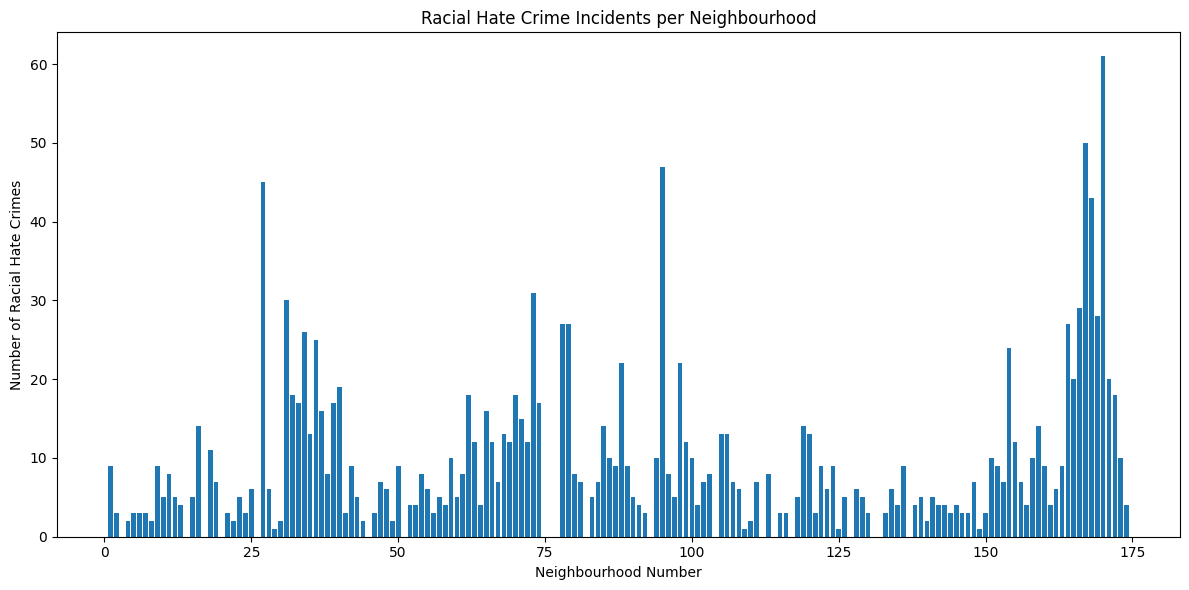

In [ ]:
plt.figure(figsize=(12, 6))
plt.bar(merged_df['Neighbourhood Number'], merged_df['Racial Hate Crimes'])

# Labels & title
plt.xlabel('Neighbourhood Number')
plt.ylabel('Number of Racial Hate Crimes')
plt.title('Racial Hate Crime Incidents per Neighbourhood')
#plt.xticks(rotation=90)  # rotate labels if needed
plt.tight_layout()
plt.show()

In [ ]:
merged_df['Percent Of Minority']= merged_df["  Total visible minority population"]/merged_df['Total - Visible minority for the population in private households - 25% sample data']
merged_df

,Total - Visible minority for the population in private households - 25% sample data,Total visible minority population,South Asian,Chinese,Black,Filipino,Arab,Latin American,Southeast Asian,West Asian,Korean,Japanese,"Visible minority, n.i.e.",Multiple visible minorities,Not a visible minority,Neighbourhood Number,Racial Hate Crimes,Percent Of Minority
0,33300,28035,13815,345,6125,2075,460,1600,530,415,130,45,1560,935,5265,1,9.0,0.841892
1,31345,27975,10195,320,8315,1160,1985,1350,450,1835,75,0,1405,870,3370,2,3.0,0.892487
2,9850,6705,2715,80,1590,205,290,645,250,370,20,0,300,240,3150,3,0.0,0.680711
3,10375,5985,1530,110,1870,575,65,725,215,220,40,20,355,255,4395,4,2.0,0.576867
4,9355,6465,780,130,2830,760,150,890,290,140,110,0,145,245,2890,5,3.0,0.691074
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
153,12645,9050,1870,3470,570,215,715,360,295,275,635,150,145,345,3600,170,61.0,0.715698
154,23180,8805,1630,1495,1755,550,210,1120,650,120,240,125,280,630,14380,171,20.0,0.379853
155,12380,3900,620,1055,540,185,75,445,285,40,190,65,115,280,8485,172,18.0,0.315024
156,15885,8160,1570,1050,1025,775,220,1050,245,1000,595,115,145,370,7730,173,10.0,0.513692


In [ ]:
X = merged_df[
    [
        'Total - Visible minority for the population in private households - 25% sample data',
        '  Total visible minority population',
        '  Not a visible minority',
        'Percent Of Minority'
    ]
]
y = merged_df['Racial Hate Crimes']

# Add a constant for the intercept
X = sm.add_constant(X)

# Fit the model
model1 = sm.OLS(y, X).fit()

# Display results
print(model1.summary())

                            OLS Regression Results                            
Dep. Variable:     Racial Hate Crimes   R-squared:                       0.166
Model:                            OLS   Adj. R-squared:                  0.144
Method:                 Least Squares   F-statistic:                     7.604
Date:                Wed, 11 Feb 2026   Prob (F-statistic):           1.30e-05
Time:                        03:02:37   Log-Likelihood:                -572.29
No. Observations:                 158   AIC:                             1155.
Df Residuals:                     153   BIC:                             1170.
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                                                                                          coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------

The results say the percentage of minority community is significant, every percent increase in percentage of minority population leads to almost 23 racial hate crime incidents more, but it only explain 16.6% of the dataset.

I don't actually know if this R2 is good bth because it relates to behaviour. Send help!

# Racial hate crime rate (for total population in 25% sample data)

That means I estimated the number of racial hate crime incidents per 10000 residents.

In [ ]:
merged_df['Total - Visible minority for the population in private households - 25% sample data'].mean()

np.float64(17476.550632911392)

In [ ]:
merged_df["Hate Crime Rate per 10000"] = (merged_df["Racial Hate Crimes"] / merged_df["Total - Visible minority for the population in private households - 25% sample data"]) * 2500
merged_df

,Total - Visible minority for the population in private households - 25% sample data,Total visible minority population,South Asian,Chinese,Black,Filipino,Arab,Latin American,Southeast Asian,West Asian,Korean,Japanese,"Visible minority, n.i.e.",Multiple visible minorities,Not a visible minority,Neighbourhood Number,Racial Hate Crimes,Percent Of Minority,Hate Crime Rate per 10000
0,33300,28035,13815,345,6125,2075,460,1600,530,415,130,45,1560,935,5265,1,9.0,0.841892,0.675676
1,31345,27975,10195,320,8315,1160,1985,1350,450,1835,75,0,1405,870,3370,2,3.0,0.892487,0.239273
2,9850,6705,2715,80,1590,205,290,645,250,370,20,0,300,240,3150,3,0.0,0.680711,0.000000
3,10375,5985,1530,110,1870,575,65,725,215,220,40,20,355,255,4395,4,2.0,0.576867,0.481928
4,9355,6465,780,130,2830,760,150,890,290,140,110,0,145,245,2890,5,3.0,0.691074,0.801710
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
153,12645,9050,1870,3470,570,215,715,360,295,275,635,150,145,345,3600,170,61.0,0.715698,12.060103
154,23180,8805,1630,1495,1755,550,210,1120,650,120,240,125,280,630,14380,171,20.0,0.379853,2.157032
155,12380,3900,620,1055,540,185,75,445,285,40,190,65,115,280,8485,172,18.0,0.315024,3.634895
156,15885,8160,1570,1050,1025,775,220,1050,245,1000,595,115,145,370,7730,173,10.0,0.513692,1.573812


In [ ]:
X = merged_df[
    [
        'Total - Visible minority for the population in private households - 25% sample data',
        '  Total visible minority population',
        '  Not a visible minority',
        'Percent Of Minority'
    ]
]
y = merged_df['Hate Crime Rate per 10000']

X = sm.add_constant(X)

model2 = sm.OLS(y, X).fit()

print(model2.summary())

                                OLS Regression Results                               
Dep. Variable:     Hate Crime Rate per 10000   R-squared:                       0.050
Model:                                   OLS   Adj. R-squared:                  0.025
Method:                        Least Squares   F-statistic:                     2.005
Date:                       Wed, 11 Feb 2026   Prob (F-statistic):             0.0966
Time:                               03:02:46   Log-Likelihood:                -291.16
No. Observations:                        158   AIC:                             592.3
Df Residuals:                            153   BIC:                             607.6
Df Model:                                  4                                         
Covariance Type:                   nonrobust                                         
                                                                                          coef    std err          t      P>|t|      [0.025 

Not good as I expected, don't know what to say :/
# Racial hate crime rate based (for visible minority population 25% sample data)
It's the estimated of racial hat crime incidents per 10,000 visible minority residents instead of per total population

In [ ]:
merged_df['  Total visible minority population'].mean()

np.float64(9729.620253164558)

In [ ]:
merged_df["Hate Crime Rate - Minority"] = (
    merged_df["Racial Hate Crimes"] / merged_df["  Total visible minority population"]
) * 2500
merged_df

,Total - Visible minority for the population in private households - 25% sample data,Total visible minority population,South Asian,Chinese,Black,Filipino,Arab,Latin American,Southeast Asian,West Asian,Korean,Japanese,"Visible minority, n.i.e.",Multiple visible minorities,Not a visible minority,Neighbourhood Number,Racial Hate Crimes,Percent Of Minority,Hate Crime Rate per 10000,Hate Crime Rate - Minority
0,33300,28035,13815,345,6125,2075,460,1600,530,415,130,45,1560,935,5265,1,9.0,0.841892,0.675676,0.802568
1,31345,27975,10195,320,8315,1160,1985,1350,450,1835,75,0,1405,870,3370,2,3.0,0.892487,0.239273,0.268097
2,9850,6705,2715,80,1590,205,290,645,250,370,20,0,300,240,3150,3,0.0,0.680711,0.000000,0.000000
3,10375,5985,1530,110,1870,575,65,725,215,220,40,20,355,255,4395,4,2.0,0.576867,0.481928,0.835422
4,9355,6465,780,130,2830,760,150,890,290,140,110,0,145,245,2890,5,3.0,0.691074,0.801710,1.160093
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
153,12645,9050,1870,3470,570,215,715,360,295,275,635,150,145,345,3600,170,61.0,0.715698,12.060103,16.850829
154,23180,8805,1630,1495,1755,550,210,1120,650,120,240,125,280,630,14380,171,20.0,0.379853,2.157032,5.678592
155,12380,3900,620,1055,540,185,75,445,285,40,190,65,115,280,8485,172,18.0,0.315024,3.634895,11.538462
156,15885,8160,1570,1050,1025,775,220,1050,245,1000,595,115,145,370,7730,173,10.0,0.513692,1.573812,3.063725


In [ ]:
X = merged_df[
    [
        'Total - Visible minority for the population in private households - 25% sample data',
        '  Total visible minority population',
        '  Not a visible minority',
        'Percent Of Minority'
    ]
]
y = merged_df['Hate Crime Rate - Minority']

X = sm.add_constant(X)

model3 = sm.OLS(y, X).fit()

print(model3.summary())

                                OLS Regression Results                                
Dep. Variable:     Hate Crime Rate - Minority   R-squared:                       0.271
Model:                                    OLS   Adj. R-squared:                  0.252
Method:                         Least Squares   F-statistic:                     14.24
Date:                        Wed, 11 Feb 2026   Prob (F-statistic):           6.61e-10
Time:                                03:03:01   Log-Likelihood:                -412.86
No. Observations:                         158   AIC:                             835.7
Df Residuals:                             153   BIC:                             851.0
Df Model:                                   4                                         
Covariance Type:                    nonrobust                                         
                                                                                          coef    std err          t      P>|t|   

The p-value says the regession is significant and explains 27.1% of the variance. Percentage of visible minority population has an inverse relationship with the hate crime rate (which is expected).

## Removing outliers

In [ ]:
target_cols = [
    'Racial Hate Crimes',
    'Hate Crime Rate per 10000',
    'Hate Crime Rate - Minority'
]

def within_iqr(df, col):
    s = pd.to_numeric(df[col], errors='coerce')
    q1, q3 = s.quantile(0.25), s.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr

    lower = max(0, lower)
    return (s >= lower) & (s <= upper)

mask = pd.Series(True, index=merged_df.index)
for col in target_cols:
    if col in merged_df.columns:
        mask = mask & within_iqr(merged_df, col)

print("Before removing outliers:", len(merged_df))
merged_df = merged_df[mask].copy()
print("After removing outliers:", len(merged_df))

Before removing outliers: 158
After removing outliers: 141


In [ ]:
eth_df = crimes_df[
    crimes_df['ETHNICITY_BIAS'].notna() & (crimes_df['ETHNICITY_BIAS'] != 'None')
].copy()

eth_df['HOOD_158'] = eth_df['HOOD_158'].astype(str).str.lstrip('0')
eth_df = eth_df[eth_df['HOOD_158'] != 'NSA']
eth_df['Neighbourhood Number'] = eth_df['HOOD_158'].astype(int)

eth_counts = (
    eth_df.groupby('Neighbourhood Number')
    .size()
    .reset_index(name='Ethnicity_Bias_Count')
)
merged_df.columns = merged_df.columns.str.strip()


In [ ]:
merged_df['Percent_Of_Minority'] = (
    merged_df['Total visible minority population'] /
    (merged_df['Total visible minority population'] + merged_df['Not a visible minority'])
)


In [ ]:

merged_df = merged_df.merge(eth_counts, on='Neighbourhood Number', how='left')

merged_df['Ethnicity_Bias_Count'] = merged_df['Ethnicity_Bias_Count'].fillna(0).astype(int)

print("Rows after merge:", len(merged_df))
print("Columns now:", merged_df.columns.tolist())



Rows after merge: 141
Columns now: ['Total - Visible minority for the population in private households - 25% sample data', 'Total visible minority population', 'South Asian', 'Chinese', 'Black', 'Filipino', 'Arab', 'Latin American', 'Southeast Asian', 'West Asian', 'Korean', 'Japanese', 'Visible minority, n.i.e.', 'Multiple visible minorities', 'Not a visible minority', 'Neighbourhood Number', 'Racial Hate Crimes', 'Percent Of Minority', 'Hate Crime Rate per 10000', 'Hate Crime Rate - Minority', 'Percent_Of_Minority', 'Ethnicity_Bias_Count']


**TRYING A LIN REG WITH MULTIPLE BIASES**

In [ ]:
crimes_df = pd.read_csv("/content/drive/MyDrive/hatecrimes1.csv")

#  identity-related bias columns
bias_cols = ['RACE_BIAS', 'ETHNICITY_BIAS']

# created a flag for any identity-related hate crime
crimes_df['IDENTITY_BIAS'] = crimes_df[bias_cols].apply(
    lambda row: any((pd.notna(x)) and (x != 'None') for x in row),
    axis=1)


In [ ]:
# Cleaning neighbourhood column
crimes_df['HOOD_158'] = crimes_df['HOOD_158'].astype(str).str.lstrip('0')
crimes_df = crimes_df[crimes_df['HOOD_158'] != 'NSA']
crimes_df['Neighbourhood Number'] = crimes_df['HOOD_158'].astype(int)

# total identity-related hate crimes per neighbourhood
identity_counts = (
    crimes_df.groupby('Neighbourhood Number')['IDENTITY_BIAS']
    .sum()
    .reset_index(name='Identity_Bias_Count')
)

# Merged with your existing merged_df
if 'Identity_Bias_Count' in merged_df.columns:
    merged_df = merged_df.drop(columns=['Identity_Bias_Count'])

merged_df = merged_df.merge(identity_counts, on='Neighbourhood Number', how='left')
merged_df['Identity_Bias_Count'] = merged_df['Identity_Bias_Count'].fillna(0)



In [ ]:
# Computing the rate per 10,000 residents
merged_df['Identity_Bias_Rate_Per10k'] = (
    merged_df['Identity_Bias_Count'] /
    (merged_df['Total visible minority population'] + merged_df['Not a visible minority'])
) * 10000

# linear reg
import statsmodels.api as sm
X = sm.add_constant(merged_df['Percent_Of_Minority'])
y = merged_df['Identity_Bias_Rate_Per10k']

model = sm.OLS(y, X).fit()
print(model.summary())


                                OLS Regression Results                               
Dep. Variable:     Identity_Bias_Rate_Per10k   R-squared:                       0.065
Model:                                   OLS   Adj. R-squared:                  0.058
Method:                        Least Squares   F-statistic:                     9.648
Date:                       Wed, 11 Feb 2026   Prob (F-statistic):            0.00230
Time:                               03:03:21   Log-Likelihood:                -284.84
No. Observations:                        141   AIC:                             573.7
Df Residuals:                            139   BIC:                             579.6
Df Model:                                  1                                         
Covariance Type:                   nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------

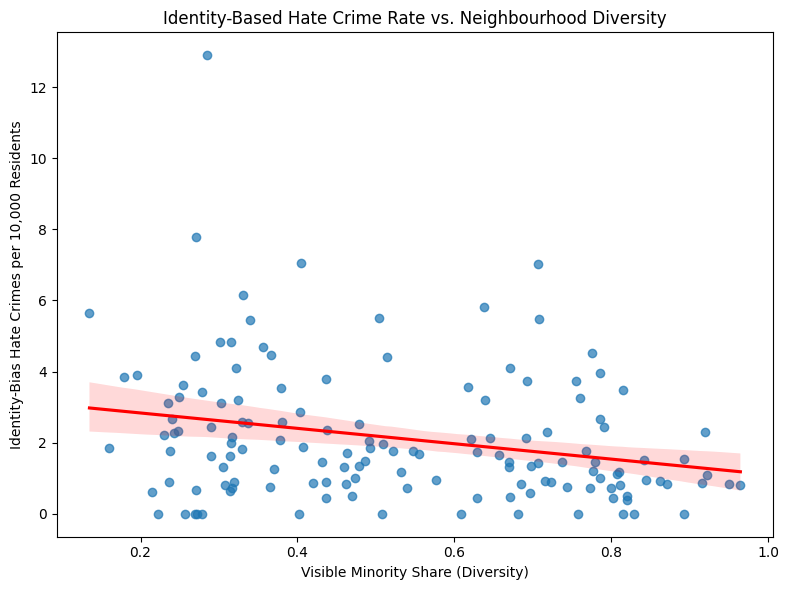

In [ ]:
# ploting the regression
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
sns.regplot(
    data=merged_df,
    x='Percent_Of_Minority',
    y='Identity_Bias_Rate_Per10k',
    scatter_kws={'alpha':0.7},
    line_kws={'color':'red'}
)
plt.xlabel('Visible Minority Share (Diversity)')
plt.ylabel('Identity-Bias Hate Crimes per 10,000 Residents')
plt.title('Identity-Based Hate Crime Rate vs. Neighbourhood Diversity')
plt.tight_layout()
plt.show()


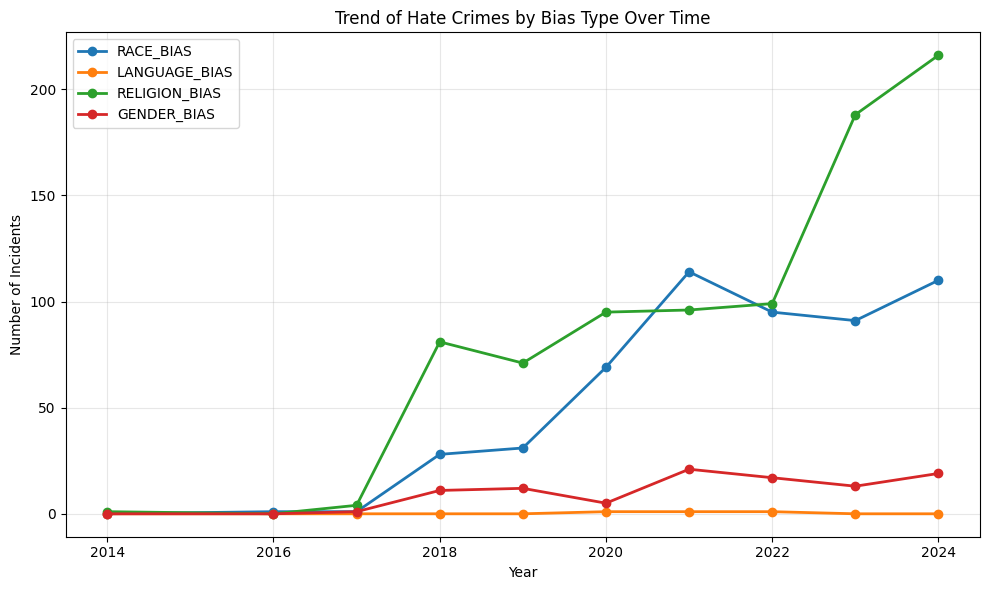

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("/content/drive/MyDrive/hatecrimes1.csv")

# Use occurrence year (you can switch to 'REPORTED_YEAR' if you want)
year_col = "OCCURRENCE_YEAR"

# These are the columns that exist in your file
bias_cols = ["RACE_BIAS", "LANGUAGE_BIAS", "RELIGION_BIAS", "GENDER_BIAS"]

# Create 1/0 indicators: 1 if bias exists for that incident, else 0
bias_flags = df[bias_cols].notna().astype(int)

# Combine year + flags, then sum by year
trend = (
    pd.concat([df[year_col], bias_flags], axis=1)
      .groupby(year_col)[bias_cols]
      .sum()
      .sort_index()
)

# Plot like your screenshot
plt.figure(figsize=(10, 6))
for col in bias_cols:
    plt.plot(trend.index, trend[col], marker="o", linewidth=2, label=col)

plt.title("Trend of Hate Crimes by Bias Type Over Time")
plt.xlabel("Year")
plt.ylabel("Number of Incidents")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()
